# Phase 1: Classical Interpretable Baselines & SHAP Explainability

This notebook implements the complete data curation, preprocessing, feature engineering, and modeling baseline pipeline for **Interpretable Machine Learning on ENCODE Genomic Data**.

### Modeling Phases Covered:
- **Phase 0**: Data download, filtering, centered resizing (1000 bp), sequence extraction, and GC-matched negative sampling.
- **Phase 1**: Classical machine learning baseline training and comparison (Logistic Regression, Random Forest, XGBoost) and SHAP explainability.

## 1. Environment Setup & Repository Integration
We pull the latest repository changes, add the package code to our search path, and dynamically install missing requirements (`xgboost` and `shap`).

In [14]:
import os
import sys
import subprocess
import importlib
import time
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, log_loss

# 1. Git pull or clone codebase
repo_dir = "/kaggle/working/interpretable-regulatory-genomics"
if not os.path.exists(repo_dir):
    print("Cloning repository...")
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PxA-Labs/interpretable-regulatory-genomics.git",
            repo_dir,
        ],
        check=True,
    )
else:
    print("Repository exists. Pulling latest updates...")
    subprocess.run(["git", "-C", repo_dir, "pull"], check=True)

# 2. Add repository directory to python search path
if repo_dir not in sys.path:
    sys.path.insert(0, repo_dir)


# 3. Auto-install missing libraries
def install_and_import(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Library '{package_name}' not found. Installing...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package_name], check=True
        )


install_and_import("xgboost")
install_and_import("shap")
install_and_import("matplotlib", "matplotlib.pyplot")

Repository exists. Pulling latest updates...
Already up to date.


## 2. Dynamic Package Module Loading
Import and reload all package submodules to verify changes and ensure updates are applied.

In [15]:
import src
import src.data
import src.data.download
import src.data.parse_encode
import src.data.sequence_extractor
import src.data.negative_sampling
import src.features
import src.features.kmer
import src.models
import src.models.base_model
import src.models.logistic
import src.models.tree_ensemble
import src.models.registry
import src.interpret
import src.interpret.shap_analysis

# Reload modules in topological dependency order
for module in [
    src,
    src.data,
    src.data.download,
    src.data.parse_encode,
    src.data.sequence_extractor,
    src.data.negative_sampling,
    src.features,
    src.features.kmer,
    src.models,
    src.models.base_model,
    src.models.logistic,
    src.models.tree_ensemble,
    src.models.registry,
    src.interpret,
    src.interpret.shap_analysis,
]:
    importlib.reload(module)

print("All pipeline modules loaded and reloaded successfully.")

All pipeline modules loaded and reloaded successfully.


## 3. Directory Initialization & Data Source Detection
Setup local output folders and scan for mounted reference genome chromosomes under `/kaggle/input/`. If not found, fallback to Test Mode (downloading chromosome 19 reference sequence).

In [16]:
raw_dir = "/kaggle/working/data/raw"
processed_dir = "/kaggle/working/data/processed"
reference_dir = "/kaggle/working/data/reference"
plot_dir = "/kaggle/working/plots"

for path in [raw_dir, processed_dir, reference_dir, plot_dir]:
    os.makedirs(path, exist_ok=True)


def detect_fasta_source():
    input_base = "/kaggle/input"
    if os.path.exists(input_base):
        for root, dirs, files in os.walk(input_base):
            has_chrom_fasta = any(
                (
                    f.startswith("chr")
                    and (
                        f.endswith(".fa")
                        or f.endswith(".fa.gz")
                        or f.endswith(".fasta")
                        or f.endswith(".fasta.gz")
                    )
                )
                for f in files
            )
            if has_chrom_fasta:
                print(f"Detected mounted reference genome at: {root}")
                return root, False

    print("Mounted hg38 dataset not found. Running in Test mode (using chr19)...")
    return reference_dir, True


fasta_source, is_test_mode = detect_fasta_source()

Mounted hg38 dataset not found. Running in Test mode (using chr19)...


## 4. Data Curation Pipeline
We download the ENCODE screen Registry V4 cCREs (human candidate cis-Regulatory Elements, file ID `ENCFF726XBE.bed.gz`), filter for PLS (Promoter-like Signature) and dELS (distal Enhancer-like Signature) classifications, and resize each sequence to a centered length of 1000 bp.

In [17]:
# A. Download ENCODE cCRE annotations
ccres_raw_path = src.data.download.download_encode_ccres(raw_dir)

if is_test_mode:
    print("Downloading chr19 reference sequence for test execution...")
    src.data.download.download_hg38_chromosome("chr19", reference_dir)
    chromosomes_to_use = ["chr19"]
else:
    chromosomes_to_use = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

# B. Parse and center-resize BED coordinates to 1000 bp
parsed_bed_path = os.path.join(processed_dir, "k562_active_ccres.bed")
src.data.parse_encode.parse_and_resize_ccres(
    input_path=ccres_raw_path,
    output_path=parsed_bed_path,
    element_types=["PLS", "dELS"],
    target_length=1000,
    chromosomes=chromosomes_to_use,
)

Download complete.
Download complete.
Parsing cCRE annotations from /kaggle/working/data/raw/ENCFF726XBE.bed.gz...
Loaded 2348854 initial regions.
Filtered by chromosomes. Remaining: 62004
Filtered by element types ['PLS', 'dELS']. Remaining: 2016
Resizing regions to fixed length of 1000 bp...
Filtered out regions with invalid coordinates. Remaining: 2016
Processed BED file saved to /kaggle/working/data/processed/k562_active_ccres.bed (Total regions: 2016).


'/kaggle/working/data/processed/k562_active_ccres.bed'

## 5. Sequence Extraction & GC-matched Negative Sampling
We extract DNA sequence strings from the reference FASTA genome chromosomes (skipping elements containing high fraction of unknown 'N' bases) and sample non-overlapping, GC-matched negative sequences from the non-coding genome regions.

In [18]:
# C. Extract sequences for the BED coordinates
extracted_tsv_path = os.path.join(processed_dir, "k562_active_ccres_sequences.tsv")
src.data.sequence_extractor.extract_sequences(
    bed_path=parsed_bed_path,
    fasta_source=fasta_source,
    output_path=extracted_tsv_path,
    max_n_fraction=0.10,
)

# D. Sample GC-stratified negative non-coding sequences
combined_dataset_path = os.path.join(processed_dir, "k562_combined_dataset.tsv")
src.data.negative_sampling.build_negative_dataset(
    pos_tsv_path=extracted_tsv_path,
    fasta_source=fasta_source,
    output_path=combined_dataset_path,
    target_length=1000,
)

Reading BED coordinates from /kaggle/working/data/processed/k562_active_ccres.bed...
Total input regions: 2,016
Loading chromosome sequence from /kaggle/working/data/reference/chr19.fa.gz...
Loaded sequence of length 58,617,616 bp.
Sequence extraction complete.
  Extracted regions: 2,016
  Skipped (out of bounds): 0
  Skipped (high N-base fraction): 0
Saved extracted sequences to /kaggle/working/data/processed/k562_active_ccres_sequences.tsv.
Loading positive regions with sequences from /kaggle/working/data/processed/k562_active_ccres_sequences.tsv...
Loading chromosome sequence from /kaggle/working/data/reference/chr19.fa.gz...
Loaded sequence of length 58,617,616 bp.
Sampling negatives for chromosome chr19...
Target negative bin counts for chr19: {12: 548, 11: 522, 13: 365, 10: 277, 14: 144, 9: 101, 15: 31, 8: 23, 16: 3, 7: 2}
Sampled 2016 / 2016 negatives for chr19 (attempts: 50513).
Saved combined positive & negative dataset to /kaggle/working/data/processed/k562_combined_dataset.t

'/kaggle/working/data/processed/k562_combined_dataset.tsv'

## 6. Feature Engineering
Compute normalized frequency distributions of $k$-mers ($k=4$, resulting in $4^4=256$ features) across the curated combined sequences dataset.

In [19]:
print("Loading combined dataset...")
df_dataset = pd.read_csv(combined_dataset_path, sep="\t")

# Extract k=4 features
X, kmer_names = src.features.kmer.extract_kmer_features(df_dataset, k=4)
y = df_dataset["label"].values

Loading combined dataset...
Extracting 4-mer features (total features: 256)...
  Processed 1000 / 4032 sequences.
  Processed 2000 / 4032 sequences.
  Processed 3000 / 4032 sequences.
  Processed 4000 / 4032 sequences.
  Processed 4032 / 4032 sequences.
k-mer feature extraction complete.


## 7. Train/Test Partition
Apply chromosome holdout split policy (training on chr1-18, X, Y; testing on chr19) in full mode. Fall back to standard stratified 80/20 partition if running in test mode on chr19.

In [20]:
if is_test_mode:
    print("Performing standard 80/20 train/test random split...")
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
else:
    print("Applying chromosome-holdout split policy (Full Mode)...")
    chroms = df_dataset["chrom"].values
    train_mask = ~np.isin(chroms, ["chr19", "chr20", "chr21", "chr22"])
    test_mask = chroms == "chr19"

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        print("Warning: Holdout chromosome(s) not found. Falling back to random split.")
        from sklearn.model_selection import train_test_split

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
    else:
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]
        print(
            f"Chromosome split: Train size = {len(X_train):,}, Test size = {len(X_test):,}"
        )

Performing standard 80/20 train/test random split...


## 8. Multi-Model Training & Evaluation Comparison
Fit Logistic Regression, Random Forest, and XGBoost classifiers via the registered `ModelRegistry` and compare metrics on the test set.

In [21]:
models_to_train = {
    "logistic_regression": {"max_iter": 1000},
    "random_forest": {"n_estimators": 500, "n_jobs": -1},
    "xgboost": {"n_estimators": 500, "n_jobs": -1, "eval_metric": "logloss"},
}

trained_models = {}
metrics_results = []

for name, params in models_to_train.items():
    print(f"\n--- Training {name.upper()} ---")
    start_time = time.time()

    model = src.models.registry.ModelRegistry.get_model(name, params)
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    y_prob = model.predict_proba(X_test)
    y_pred = model.predict(X_test)

    auroc = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    loss = log_loss(y_test, y_prob)

    metrics_results.append(
        {
            "Model": name.upper(),
            "AUROC": auroc,
            "AUPRC": auprc,
            "F1-Score": f1,
            "Log Loss": loss,
            "Train Time (s)": elapsed_time,
        }
    )

    trained_models[name] = model

df_metrics = pd.DataFrame(metrics_results)
print("\n=================== PERFORMANCE METRICS COMPARISON ===================")
print(df_metrics.to_string(index=False))
print("======================================================================\n")


--- Training LOGISTIC_REGRESSION ---

--- Training RANDOM_FOREST ---

--- Training XGBOOST ---

=================== PERFORMANCE METRICS COMPARISON ===================
              Model    AUROC    AUPRC  F1-Score  Log Loss  Train Time (s)
LOGISTIC_REGRESSION 0.767892 0.715633  0.724936  0.660168        0.014673
      RANDOM_FOREST 0.867516 0.887250  0.783163  0.479692        3.361717
            XGBOOST 0.882097 0.894698  0.800505  0.604551        1.174485



## 9. Feature Importance Analysis
Print top positive/negative coefficients from Logistic Regression and top Gini features from Random Forest.

In [22]:
# A. Logistic Regression importances
lr_importance = trained_models["logistic_regression"].get_feature_importance(kmer_names)
lr_pos = lr_importance.sort_values(by="importance", ascending=False).head(10)
lr_neg = lr_importance.sort_values(by="importance", ascending=True).head(10)
print("Top 10 positive k-mers (enhancer/promoter associated):")
print(lr_pos.to_string(index=False))
print("\nTop 10 negative k-mers (non-regulatory associated):")
print(lr_neg.to_string(index=False))

# B. Random Forest Gini importances
rf_importance = trained_models["random_forest"].get_feature_importance(kmer_names)
print("\nTop 10 features by Random Forest Gini importance:")
print(rf_importance.head(10).to_string(index=False))

Top 10 positive k-mers (enhancer/promoter associated):
feature  importance
   GCGG    2.603100
   GGCG    2.492842
   GCGC    2.419090
   CGCG    2.310353
   CCGC    2.183354
   CGCC    2.011676
   CGGG    1.926933
   CCCG    1.645339
   CCGG    1.510887
   CGGC    1.452673

Top 10 negative k-mers (non-regulatory associated):
feature  importance
   CCTG   -1.806000
   CAGG   -1.724881
   CCAG   -1.721103
   CCCA   -1.641192
   CTGG   -1.617578
   TGGG   -1.335662
   CCTC   -1.326090
   CACC   -1.239595
   TGCC   -1.132068
   CAGC   -1.113608

Top 10 features by Random Forest Gini importance:
feature  importance
   CGCG    0.027884
   CCGC    0.019809
   GCGC    0.019303
   GCGG    0.015647
   GGCG    0.014887
   CAGG    0.012905
   CCAG    0.011843
   TCCG    0.011700
   CCTG    0.011588
   GCGA    0.011294


## 10. SHAP Explainability & Inline Beeswarm Plotting
Use SHAP `TreeExplainer` on our trained XGBoost model to compute sequence attributions and display the Beeswarm summary plot directly in the notebook output.


--- Running SHAP explainability on XGBoost ---
Initializing SHAP TreeExplainer...
Computing SHAP values (this may take a minute depending on model depth)...
SHAP values calculated successfully.


/kaggle/working/interpretable-regulatory-genomics/src/interpret/shap_analysis.py:77: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


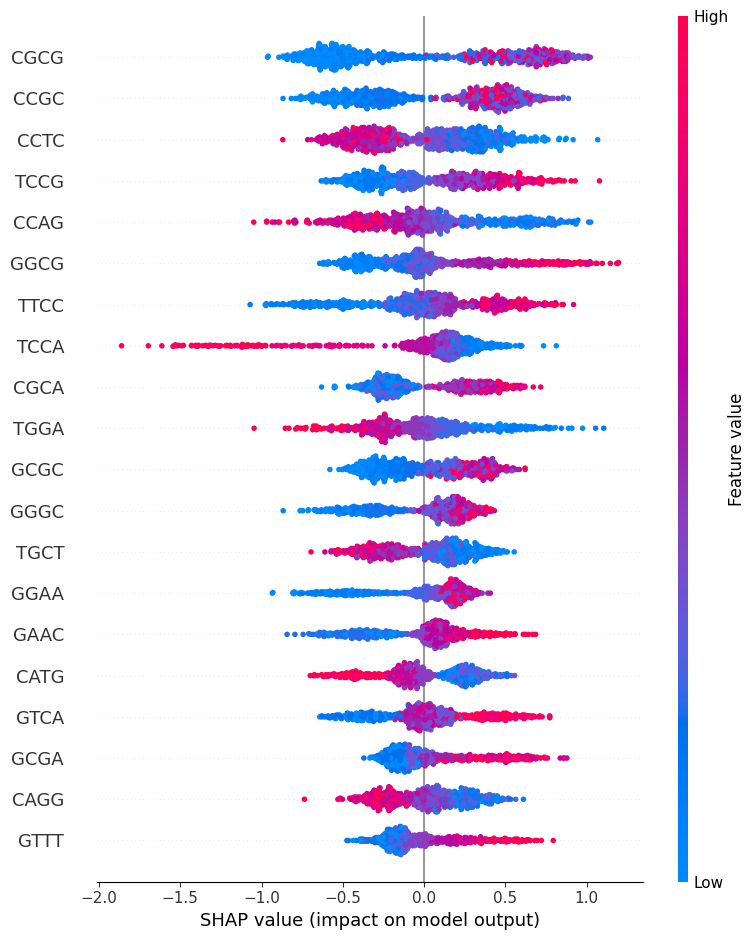

SHAP summary plot saved to /kaggle/working/plots/xgboost_shap_summary.png.

Top 20 Features by Mean Absolute SHAP Value:
feature  mean_abs_shap
   CGCG       0.541813
   CCGC       0.417748
   CCTC       0.315230
   TCCG       0.312122
   CCAG       0.311290
   GGCG       0.301026
   TTCC       0.294630
   TCCA       0.280798
   CGCA       0.272163
   TGGA       0.255728
   GCGC       0.248485
   GGGC       0.241161
   TGCT       0.225547
   GGAA       0.224661
   GAAC       0.220618
   CATG       0.219204
   GTCA       0.215643
   GCGA       0.204493
   CAGG       0.197243
   GTTT       0.191662

Rendering saved SHAP beeswarm plot:


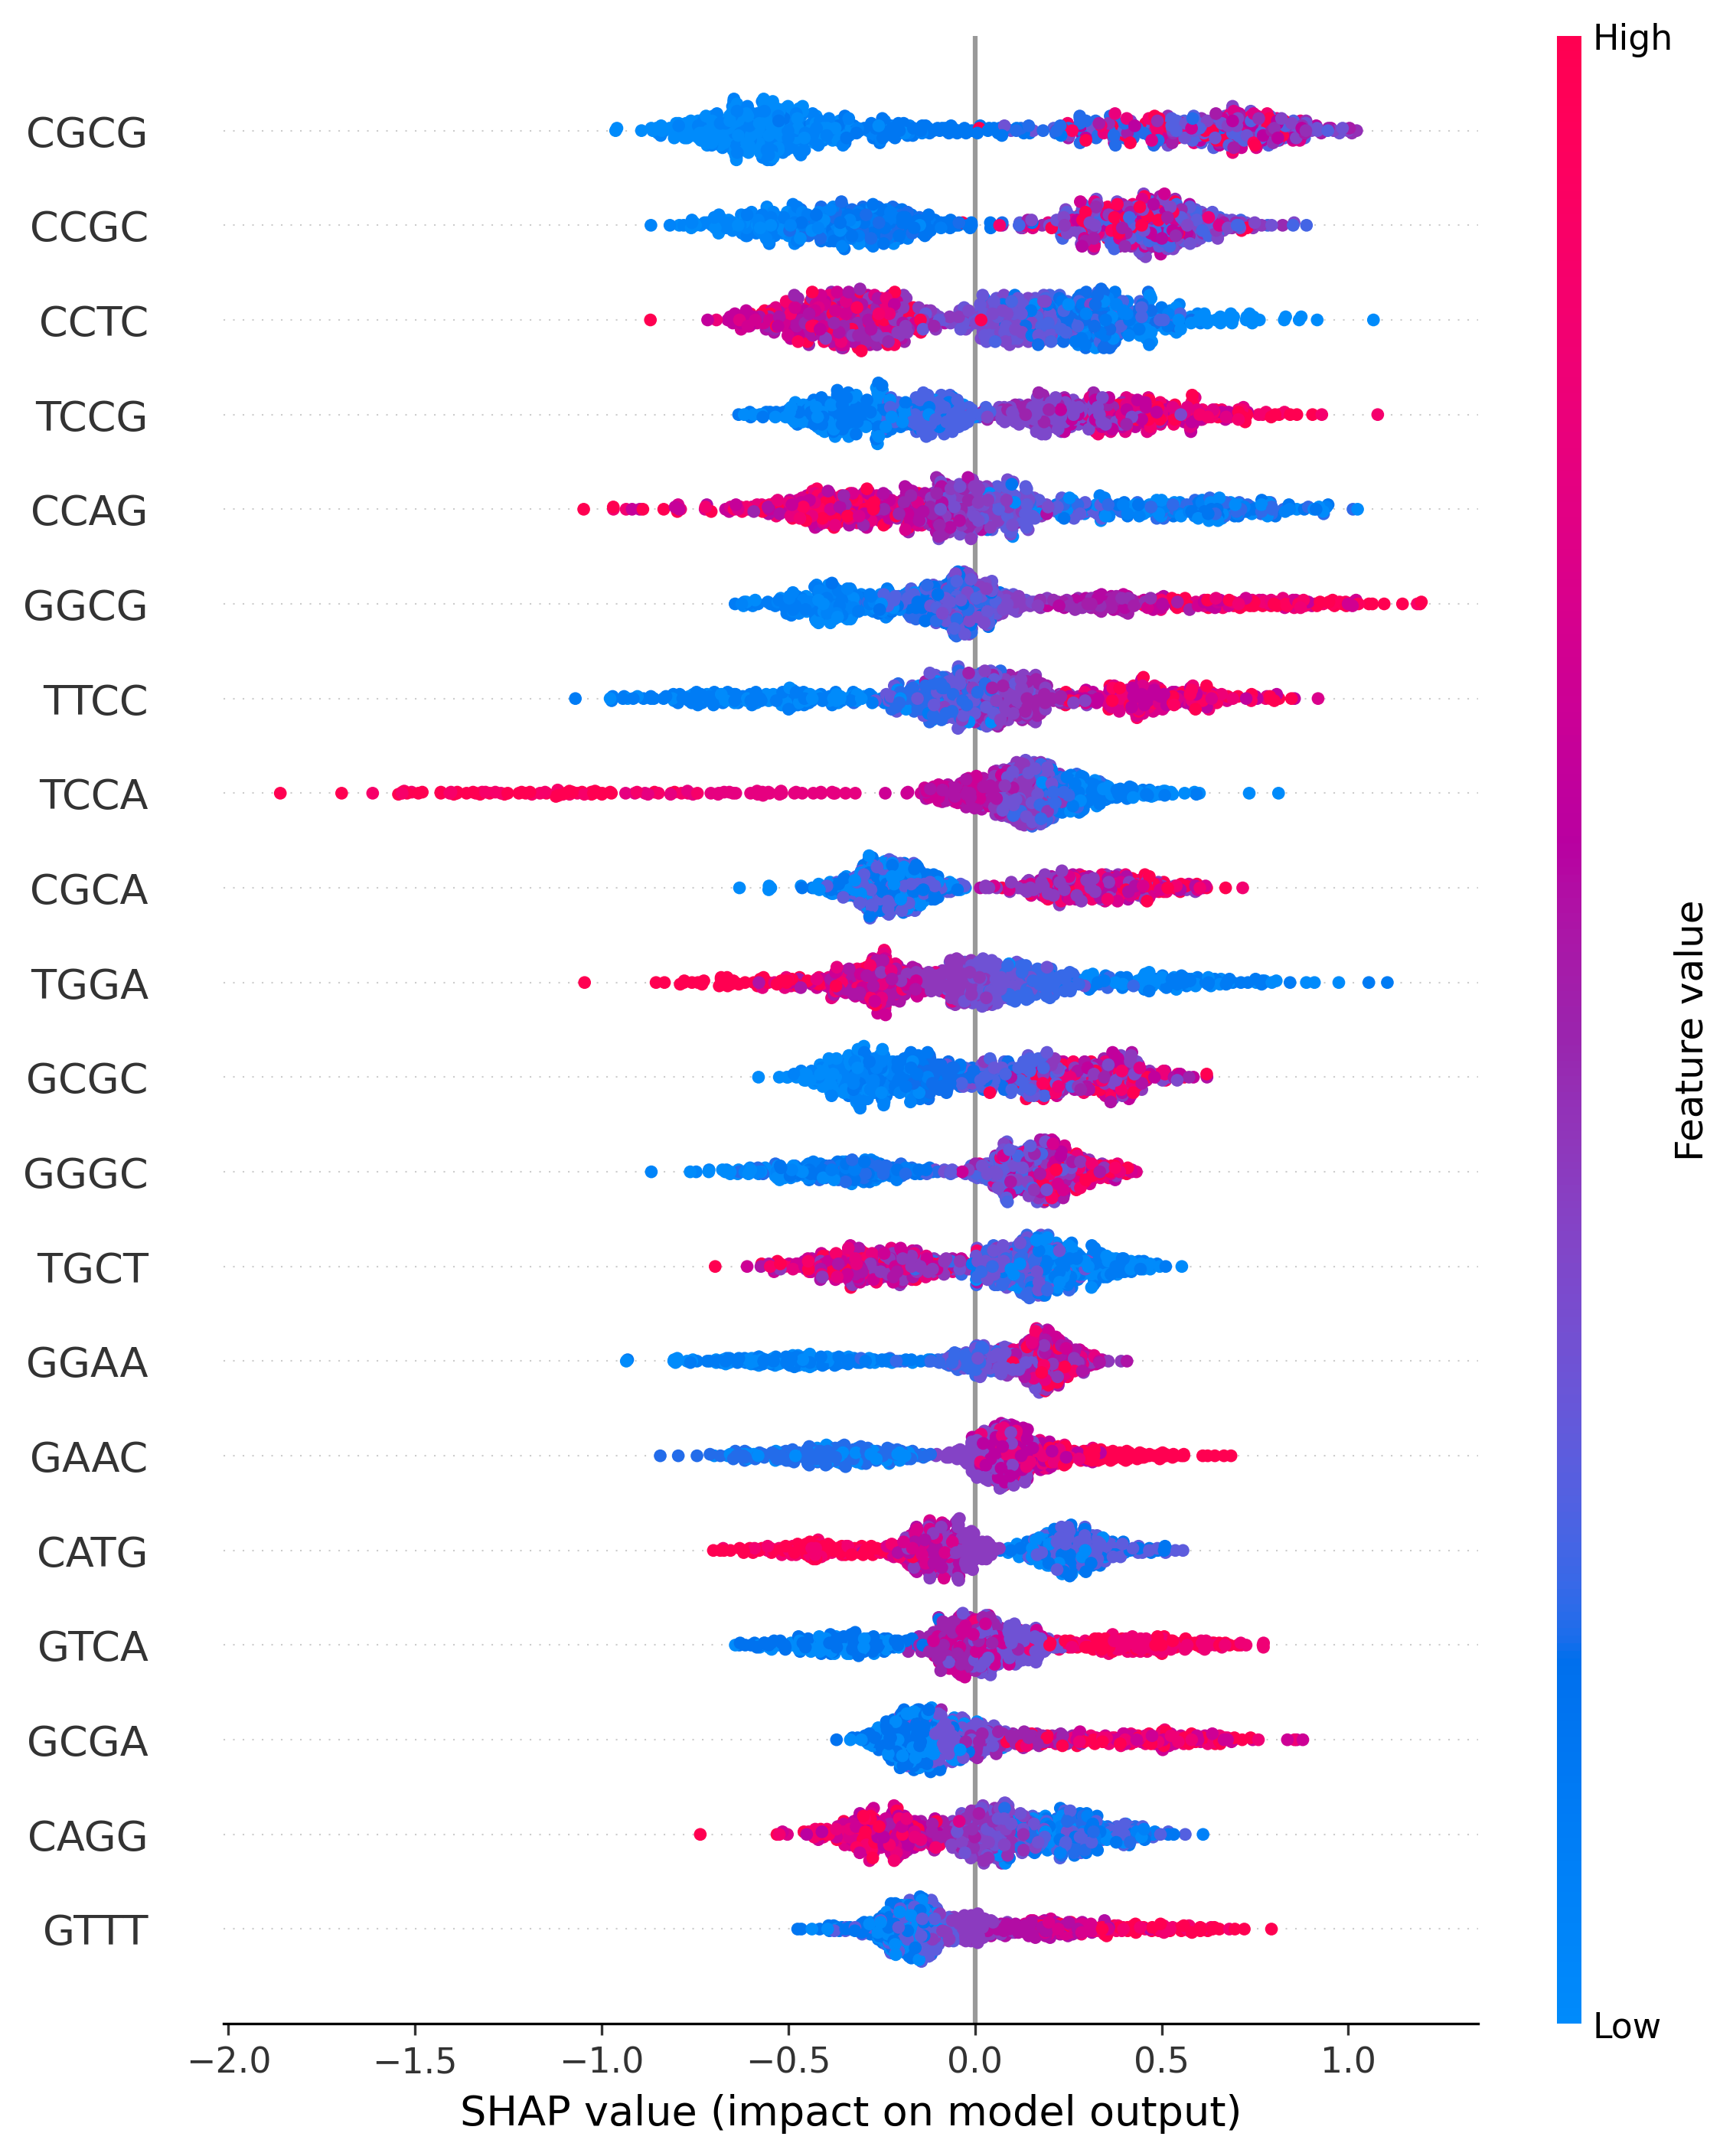

In [23]:
shap_plot_path = os.path.join(plot_dir, "xgboost_shap_summary.png")
print("\n--- Running SHAP explainability on XGBoost ---")

# Sample 1000 regions for speed and memory efficiency
explain_size = min(1000, len(X_test))
np.random.seed(42)
explain_idx = np.random.choice(len(X_test), explain_size, replace=False)
X_explain = X_test[explain_idx]

shap_values = src.interpret.shap_analysis.explain_model_shap(
    model=trained_models["xgboost"],
    X_explain=X_explain,
    feature_names=kmer_names,
    output_plot_path=shap_plot_path,
    max_display=20,
    show_plot=True,
)

# Display SHAP importances table
top_shap_features = src.interpret.shap_analysis.get_top_shap_features(
    shap_values, kmer_names, top_n=20
)
print("\nTop 20 Features by Mean Absolute SHAP Value:")
print(top_shap_features.to_string(index=False))

# Fail-safe rendering
try:
    from IPython.display import Image, display

    print("\nRendering saved SHAP beeswarm plot:")
    display(Image(filename=shap_plot_path))
except Exception as e:
    print(f"Notice: IPython display fail: {e}")